<a href="https://colab.research.google.com/github/TunggTungg/AI_EXERCISEs/blob/main/BT_AI_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Modules

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from keras.utils import np_utils
from sklearn.utils import shuffle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow as tf
import math as m

In [ ]:
def plot_history(history_fine):
  f1 = history_fine.history['acc']
  val_f1 = history_fine.history['val_acc']

  loss = history_fine.history['loss']
  val_loss = history_fine.history['val_loss']

  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(f1, label='Acc')
  plt.plot(val_f1, label='Validation Acc')
  plt.legend(loc='lower right')
  plt.title('Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Loss')
  plt.xlabel('epoch')
  plt.show()

def plot_reg_history(history_fine):
  loss = history_fine.history['loss']
  val_loss = history_fine.history['val_loss']
  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Loss')
  plt.xlabel('epoch')
  plt.show()

# 1.NHẬN DẠNG KHUÔN MẶT (ANN)

## 1.1 Load Data

In [ ]:
# Load Data 
with open('data.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Reshape Data
x_pre = x_train[101]
x_train = x_train[:194]
y_train = y_train[:194]
x_train = x_train.reshape(x_train.shape[0], -1)

# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train, 2)

# Shuffe Data
x_train, y_train = shuffle(x_train, y_train)

## 1.2 Create Model

Epoch 1/50
5/5 [==============================] - 1s 53ms/step - loss: 0.6937 - acc: 0.5419 - val_loss: 0.6936 - val_acc: 0.4359
Epoch 2/50
5/5 [==============================] - 0s 14ms/step - loss: 0.6923 - acc: 0.5355 - val_loss: 0.6908 - val_acc: 0.4359
Epoch 3/50
5/5 [==============================] - 0s 13ms/step - loss: 0.6876 - acc: 0.6968 - val_loss: 0.6837 - val_acc: 0.9231
Epoch 4/50
5/5 [==============================] - 0s 13ms/step - loss: 0.6793 - acc: 0.9742 - val_loss: 0.6746 - val_acc: 1.0000
Epoch 5/50
5/5 [==============================] - 0s 14ms/step - loss: 0.6700 - acc: 0.9871 - val_loss: 0.6659 - val_acc: 1.0000
Epoch 6/50
5/5 [==============================] - 0s 14ms/step - loss: 0.6631 - acc: 1.0000 - val_loss: 0.6567 - val_acc: 1.0000
Epoch 7/50
5/5 [==============================] - 0s 14ms/step - loss: 0.6509 - acc: 1.0000 - val_loss: 0.6431 - val_acc: 1.0000
Epoch 8/50
5/5 [==============================] - 0s 18ms/step - loss: 0.6388 - acc: 1.0000 - val

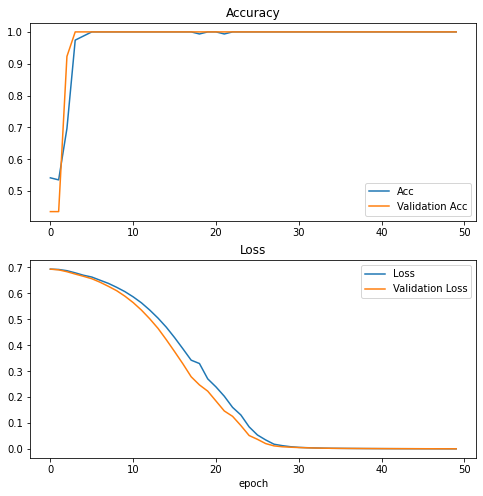

In [ ]:
model = Sequential()
model.add(Dense(10, activation='relu', input_shape = (67500,)))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 32, epochs = 50, validation_split = 0.2)

plot_history(history)

## 1.3 Predict

(150, 150, 3)


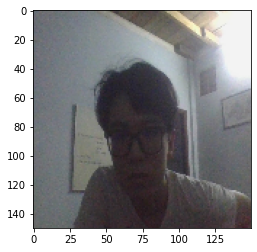

In [ ]:
# Load Test Image
plt.imshow(cv2.cvtColor(x_pre, cv2.COLOR_BGR2RGB))
print(x_pre.shape)
img = x_pre.reshape(1,-1)
img = img.astype('float32')
img /= 255

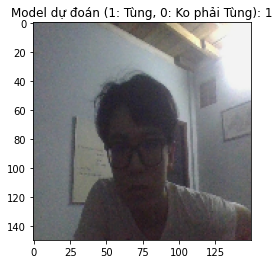

In [ ]:
plt.title("Model dự đoán (1: Tùng, 0: Ko phải Tùng): " + str(np.argmax(model.predict(img))))
plt.imshow(cv2.cvtColor(x_pre, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

# 2.ROBOT 2 BẬC

## 2.1 Create Data

In [ ]:
from sklearn.preprocessing import StandardScaler
# Define Variables
l1 = 40
l2 = 50
x_train = []
y_train = []

# Create Data
for t1 in np.linspace(-(2 * np.pi), 2 * np.pi, 500):
  for t2 in np.linspace(-(2 * np.pi), 2 * np.pi, 500):
    x = l1*m.cos(t1) + l2*m.cos(t1+t2)
    y = l1*m.sin(t1) + l2*m.sin(t1+t2)
    x_train.append(np.array([x,y]))
    y_train.append(np.array([t1,t2]))

# Convert to array
scaler = StandardScaler()
x_train = np.array(scaler.fit_transform(x_train))
y_train = np.array(y_train)

# Shuffe
x_train, y_train = shuffle(x_train, y_train)

## 2.2 Create Model

Epoch 1/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1464 - val_loss: 3.1556
Epoch 2/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1463 - val_loss: 3.1558
Epoch 3/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1462 - val_loss: 3.1560
Epoch 4/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1462 - val_loss: 3.1562
Epoch 5/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1462 - val_loss: 3.1563
Epoch 6/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1461 - val_loss: 3.1563
Epoch 7/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1461 - val_loss: 3.1566
Epoch 8/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1461 - val_loss: 3.1568
Epoch 9/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1461 - val_loss: 3.1567
Epoch 10/10
391/391 [==============================] - 3s 7ms/step - loss: 3.1460 - val_loss: 3.1569

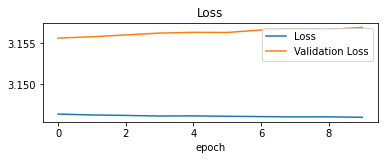

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape = (2,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(2, activation='linear'))

model.compile(loss='mae', optimizer =tf.optimizers.Adam(learning_rate=0.0001))

history = model.fit(x_train, y_train, batch_size = 512, epochs = 10, validation_split = 0.2)

plot_reg_history(history)

## 2.3 Predict

In [ ]:
# Input x =90, y = 0
test = scaler.transform(np.array([[90,0]]))
t1 = model.predict(test)[0][0]
t2 = model.predict(test)[0][1]

x = l1*m.cos(t1) + l2*m.cos(t2+t1)
y = l1*m.sin(t1) + l2*m.sin(t2+t1)

print("Model dự đoán với giá trị đầu vào x = 90 và y = 0 là t1 = " + str(t1) + " t2 = "+ str(t2))
print("Kiểm tra: ")
print("Với giá trị t1 và t2 dự đoán ta tính lại x = " + str(x) + " y = "+ str(y))

Model dự đoán với giá trị đầu vào x = 90 và y = 0 là t1 = 0.012898436 t2 = 0.015850868
Kiểm tra: 
Với giá trị t1 và t2 dự đoán ta tính lại x = 89.97601101451176 y = 1.9531903132919717


# 3.ROBOT 3 BẬC

## 3.1 Create Data

In [ ]:
from sklearn.preprocessing import StandardScaler
# Define Variables
l1 = 40
l2 = 50
l3 = 20
x_train = []
y_train = []

# Create Data
for t1 in np.linspace(-(2 * np.pi), 2 * np.pi, 100):
  for t2 in np.linspace(-(2 * np.pi), 2 * np.pi, 100):
    for t3 in np.linspace(-(2 * np.pi), 2 * np.pi, 100):
      x = l1*m.cos(t1) + l2*m.cos(t1+t2) + l3*m.cos(t1+t2+t3)
      y = l1*m.sin(t1) + l2*m.sin(t1+t2) + l3*m.sin(t1+t2+t3)
      beta = (t1 + t2 + t3)*180/3.14
      x_train.append(np.array([x,y,beta]))
      y_train.append(np.array([t1,t2,t3]))

# Convert to array
scaler = StandardScaler()
x_train = np.array(scaler.fit_transform(x_train))
y_train = np.array(y_train)

# Shuffe
x_train, y_train = shuffle(x_train, y_train)

## 3.2 Create Model

Epoch 1/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.4562 - val_loss: 2.3895
Epoch 2/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3822 - val_loss: 2.3700
Epoch 3/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3647 - val_loss: 2.3552
Epoch 4/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3528 - val_loss: 2.3459
Epoch 5/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3449 - val_loss: 2.3394
Epoch 6/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3388 - val_loss: 2.3338
Epoch 7/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3340 - val_loss: 2.3293
Epoch 8/10
1563/1563 [==============================] - 10s 7ms/step - loss: 2.3301 - val_loss: 2.3256
Epoch 9/10
1563/1563 [==============================] - 10s 7ms/step - loss: 2.3266 - val_loss: 2.3228
Epoch 10/10
1563/1563 [==============================] - 10s 7ms/step - l

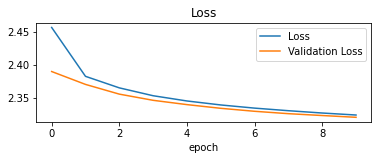

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape = (3,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(3, activation='linear'))

model.compile(loss='mae', optimizer =tf.optimizers.Adam(learning_rate=0.0001))

history = model.fit(x_train, y_train, batch_size = 512, epochs = 10, validation_split = 0.2)

plot_reg_history(history)

## 3.3 Predict

In [ ]:
# Input x =45, y = 45, beta = 90
test = scaler.transform(np.array([[75,0,45]]))
t1 = model.predict(test)[0][0]
t2 = model.predict(test)[0][1]
t3 = model.predict(test)[0][2]

x = l1*m.cos(t1) + l2*m.cos(t1+t2) + l3*m.cos(t1+t2+t3)
y = l1*m.sin(t1) + l2*m.sin(t1+t2) + l3*m.sin(t1+t2+t3)
beta = (t1 + t2 + t3)*180/3.14

print("Model dự đoán với giá trị đầu vào x = 90, y = 0 và beta = 45 là t1 = " + str(t1) + " t2 = "+ str(t2) + " t3 = "+ str(t3))
print("Kiểm tra: ")
print("Với giá trị t1 và t2 dự đoán ta tính lại x = " + str(x) + " y = "+ str(y)+ " beta = "+ str(beta))

Model dự đoán với giá trị đầu vào x = 90, y = 0 và beta = 45 là t1 = 0.031406686 t2 = 0.131782 t3 = 0.6536052
Kiểm tra: 
Với giá trị t1 và t2 dự đoán ta tính lại x = 103.00722274403682 y = 23.958424504417167 beta = 46.822581321570524


# 4.Nhận Dạng Khuôn Mặt (CNN)

## 4.1 Load Data

In [ ]:
# Load Data 
with open('data.pickle', 'rb') as f:
    (x_train, y_train) = pickle.load(f)

# Reshape Data
x_pre_1 = x_train[101]
x_pre_2 = x_train[201]
x_pre_3 = x_train[301]


# Preprocessing Data
x_train = x_train.astype('float32')
x_train /= 255

# Encoding Y
y_train = np_utils.to_categorical(y_train, 4)

# Shuffe Data
x_train, y_train = shuffle(x_train, y_train)

## 4.2 Create Model

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (150,150,3)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(64, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(Conv2D(128, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(4, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 75, 75, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                    

In [ ]:
opt = Adam(lr = 0.001)
model.compile(optimizer = opt, loss = 'categorical_crossentropy', metrics = ['acc'])
his = model.fit(x_train, y_train, epochs = 15, batch_size = 64, validation_split = 0.2)

Epoch 1/15


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


5/5 [==============================] - 2s 215ms/step - loss: 2.0941 - acc: 0.8270 - val_loss: 0.2580 - val_acc: 0.8875
Epoch 2/15
5/5 [==============================] - 1s 136ms/step - loss: 0.0923 - acc: 0.9528 - val_loss: 0.0043 - val_acc: 1.0000
Epoch 3/15
5/5 [==============================] - 1s 137ms/step - loss: 0.0335 - acc: 0.9843 - val_loss: 2.4558e-04 - val_acc: 1.0000
Epoch 4/15
5/5 [==============================] - 1s 137ms/step - loss: 1.8502e-04 - acc: 1.0000 - val_loss: 9.8852e-06 - val_acc: 1.0000
Epoch 5/15
5/5 [==============================] - 1s 135ms/step - loss: 1.6760e-06 - acc: 1.0000 - val_loss: 2.1397e-06 - val_acc: 1.0000
Epoch 6/15
5/5 [==============================] - 1s 135ms/step - loss: 9.5803e-05 - acc: 1.0000 - val_loss: 3.9339e-07 - val_acc: 1.0000
Epoch 7/15
5/5 [==============================] - 1s 135ms/step - loss: 1.4770e-07 - acc: 1.0000 - val_loss: 1.4901e-09 - val_acc: 1.0000
Epoch 8/15
5/5 [==============================] - 1s 137ms/step -

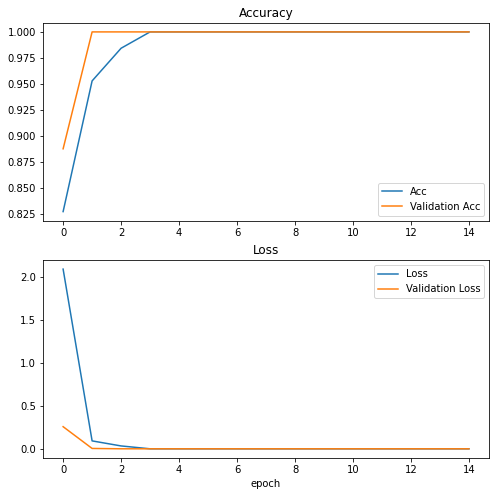

In [ ]:
plot_history(his)

## 4.3 Predict

In [ ]:
label = ['None', 'Tùng', 'Thành', 'Ninh']

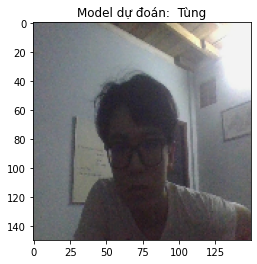

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_1.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_1, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

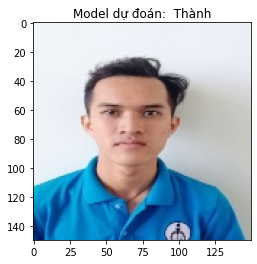

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_2.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_2, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))

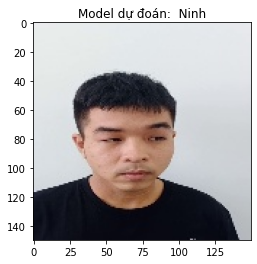

In [ ]:
plt.title("Model dự đoán:  " + label[np.argmax(model.predict(x_pre_3.reshape(1,150,150,3)))])
plt.imshow(cv2.cvtColor(x_pre_3, cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))